1 - Loading the dataset

In [10]:
import numpy as np

data = np.loadtxt("ca-asTroPh.txt")

### test data loading and print shape
print("Data shape:", data.shape)
print("First 5 rows:\n", data[:5] if data.size > 0 else "failed to load")

Data shape: (396160, 2)
First 5 rows:
 [[84424.   276.]
 [84424.  1662.]
 [84424.  5089.]
 [84424.  6058.]
 [84424.  6229.]]


In [11]:
import networkx as nx

G = nx.Graph()

for row in data:
    node1, node2 = int(row[0]), int(row[1])
    if G.has_edge(node1, node2):
        G[node1][node2]['weight']+=1
    else:
        G.add_edge(node1, node2, weight = 1)

### printing for verif:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Sample edges with weights:", list(G.edges(data=True))[:5])

Number of nodes: 18772
Number of edges: 198110
Sample edges with weights: [(84424, 276, {'weight': 2}), (84424, 1662, {'weight': 2}), (84424, 5089, {'weight': 2}), (84424, 6058, {'weight': 2}), (84424, 6229, {'weight': 2})]


2 - Extracting features from the egonet

In [12]:
node_attributes = {}

for node in G.nodes():
    #number of neighbors
    Ni = len(list(G.neighbors(node)))
    
    # Egonet: subgraph induced by node and its neighbors
    egonet_nodes = list(G.neighbors(node)) + [node]
    egonet = G.subgraph(egonet_nodes)
    
    #number of edges in egonet
    Ei = egonet.number_of_edges()
    
    #total weight of egonet (sum of edge weights)
    Wi = sum(data['weight'] for _, _, data in egonet.edges(data=True))
    
    #principal eigenvalue of weighted adjacency matrix
    if egonet.number_of_nodes() > 0:
        adj_matrix = nx.adjacency_matrix(egonet, weight='weight').todense()
        eigenvalues = np.linalg.eigvals(adj_matrix)
        lambda_w_i = max(eigenvalues.real)  # principal eigenvalue (largest real part)
    else:
        lambda_w_i = 0
    
    node_attributes[node] = {
        'Ni': Ni,
        'Ei': Ei,
        'Wi': Wi,
        'lambda_w_i': lambda_w_i
    }

nx.set_node_attributes(G, node_attributes)

###print sample to verify
print("Sample node attributes:", dict(list(G.nodes(data=True))[:3]))

Sample node attributes: {84424: {'Ni': 75, 'Ei': 286, 'Wi': 571, 'lambda_w_i': np.float64(25.894897319491687)}, 276: {'Ni': 31, 'Ei': 86, 'Wi': 171, 'lambda_w_i': np.float64(16.542559057832214)}, 1662: {'Ni': 43, 'Ei': 262, 'Wi': 523, 'lambda_w_i': np.float64(32.47812260195306)}}


3 - Anomaly scores

In [13]:
from sklearn.linear_model import LinearRegression

log_x = []
log_y = []

for node in G.nodes():
    Ni - G.nodes[node]['Ni']
    Ei - G.nodes[node]['Ei']
    if Ni > 0 and Ei > 0:
        log_x.append(np.log(Ni))
        log_y.append(np.log(Ei))

log_x = np.array(log_x).reshape(-1, 1)
log_y = np.array(log_y)

lin_reg = LinearRegression()
lin_reg.fit(log_x, log_y)

C = np.exp(lin_reg.intercept_)
theta = lin_reg.coef_[0]

anom_scores = {}
for node in G.nodes():
    score = 0
    Ni = G.nodes[node]['Ni']
    Ei = G.nodes[node]['Ei']
    if Ni > 0:
        Ei_pred = C * (Ni ** theta)
        diff = Ei - Ei_pred
        score = max(Ei, Ei_pred) - min(Ei, Ei_pred) + np.log(np.abs(diff) + 1)
    anom_scores[node] = score

nx.set_node_attributes(G, anom_scores, 'anomaly_score')

###print samples to verify
print("Sample anomaly scores:", {node: G.nodes[node]['anomaly_score'] for node in list(G.nodes())[:3]})


Sample anomaly scores: {84424: np.float64(290.65599181081984), 276: np.float64(89.4543472962535), 1662: np.float64(266.56834450376107)}


Step before 4 and 5 - create a subgraph with the first 1500 rows

In [14]:
data_15 =  np.loadtxt("ca-asTroPh.txt")[:1500]

G_sub = nx.Graph()

for row in data_15:
    node1, node2 = int(row[0]), int(row[1])
    if G_sub.has_edge(node1, node2):
        G_sub[node1][node2]['weight']+=1
    else:
        G_sub.add_edge(node1, node2, weight = 1)

4 - Sorting the scores in decending order and drawing graph

In [16]:
sorted_nodes = sorted(G_sub.nodes(), key=lambda n: G.nodes[n]['anomaly_score'], reverse=True)
print("Top 10 nodes by anomaly score:", sorted_nodes[:10])

Top 10 nodes by anomaly score: [53213, 38109, 92790, 21718, 35290, 94235, 34608, 111161, 75947, 23986]


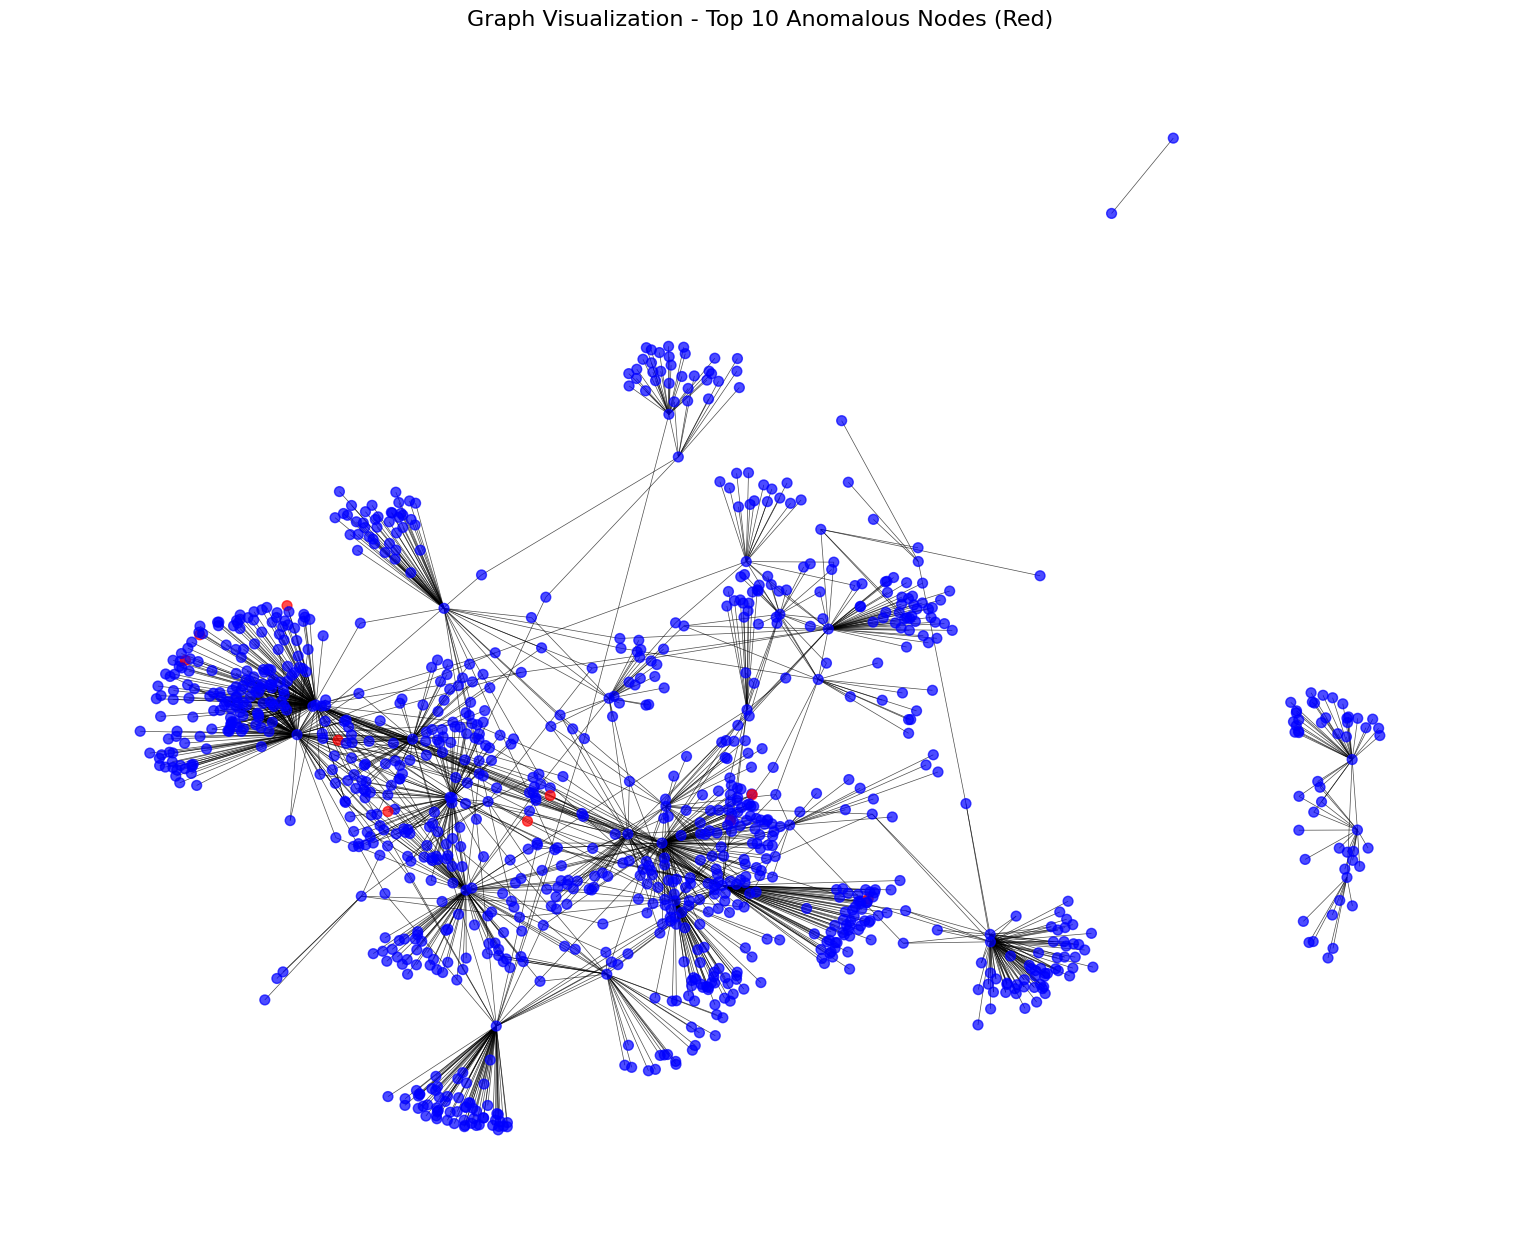

In [20]:
import matplotlib.pyplot as plt

top_10_nodes = sorted_nodes[:10]

node_colors = ['red' if node in top_10_nodes else 'blue' for node in G_sub.nodes()]

plt.figure(figsize=(15, 12))
pos = nx.spring_layout(G_sub, k=0.5, iterations=50, seed=42)
nx.draw(G_sub, pos, node_color=node_colors, node_size=50, 
        width=0.5, alpha=0.7, with_labels=False)
plt.title('Graph Visualization - Top 10 Anomalous Nodes (Red)', fontsize=16)
plt.axis('off')
plt.show()

5 - Modified Anomaly Scores

Top 10 nodes by combined anomaly score: [53213, 38109, 92790, 21718, 35290, 94235, 34608, 111161, 75947, 23986]


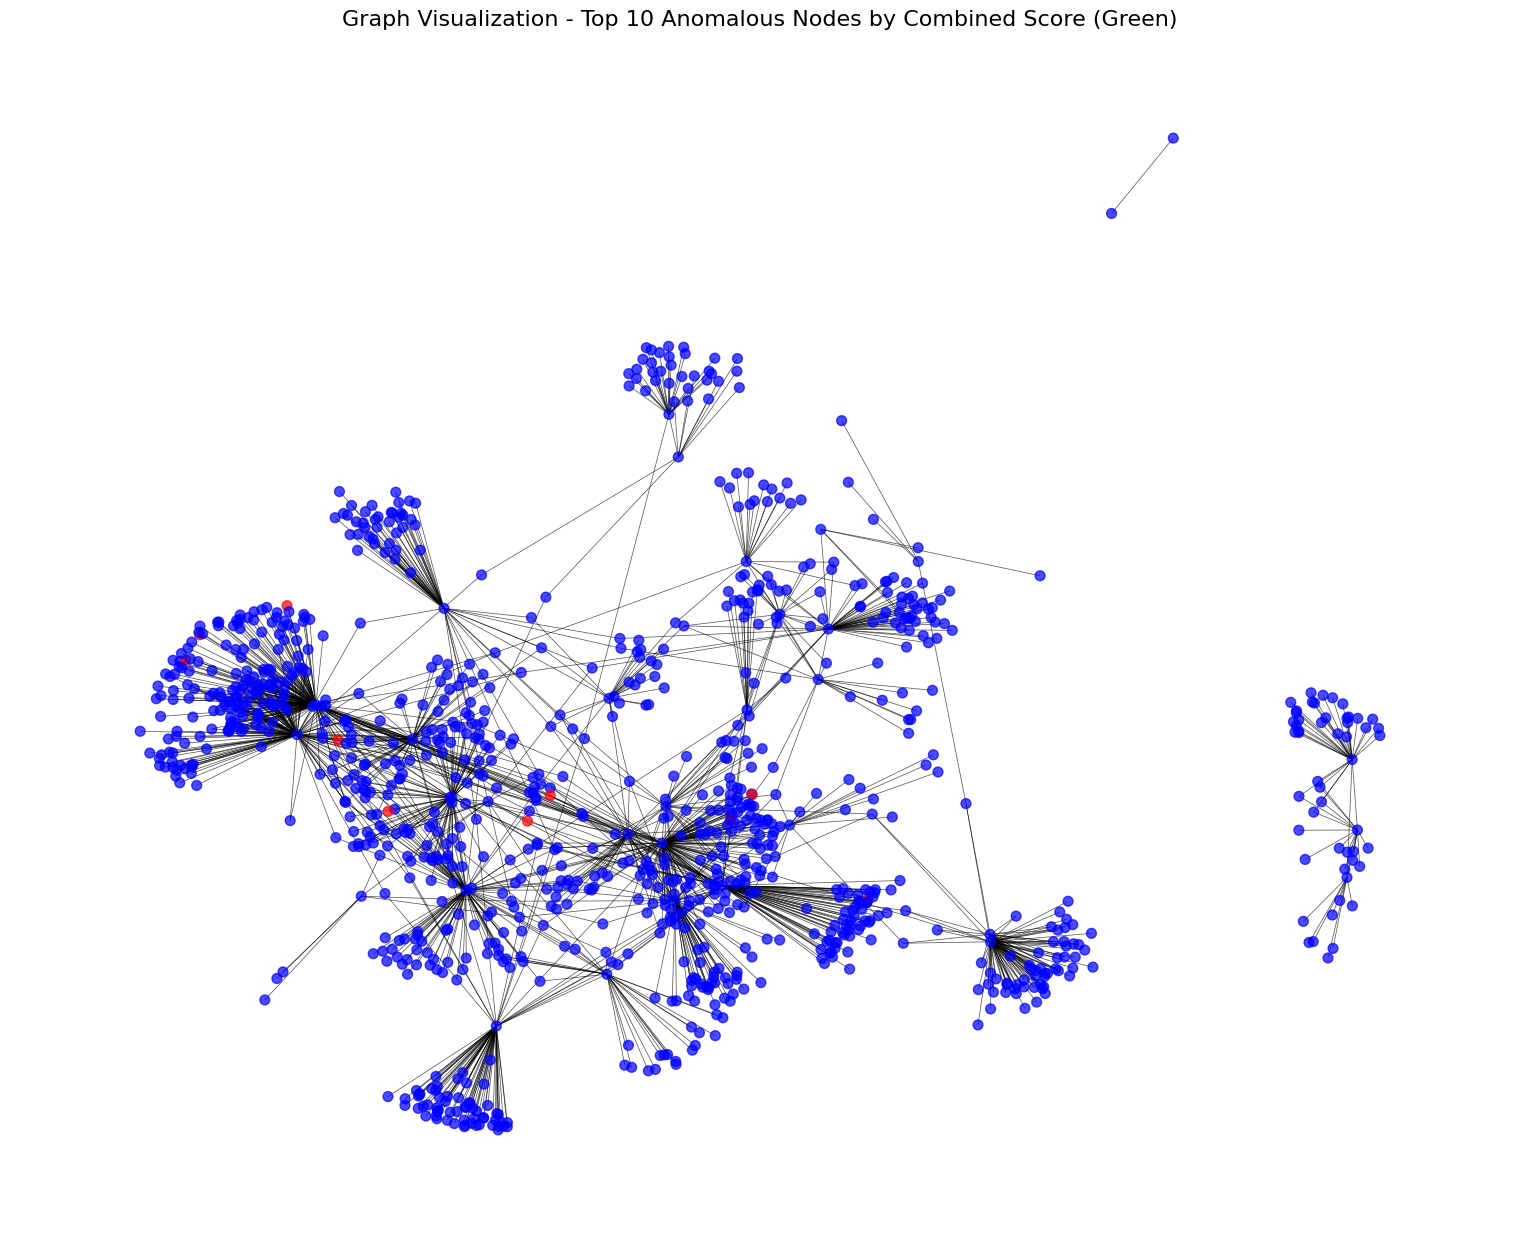

In [25]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler

lof_data = []
node_list = list(G_sub.nodes())
for node in node_list:
    Ni = G.nodes[node]['Ni']
    Ei = G.nodes[node]['Ei']
    lof_data.append([Ni, Ei])

lof_data = np.array(lof_data)
lof = LocalOutlierFactor(n_neighbors=30, contamination='auto')
lof.fit_predict(lof_data)
lof_scores = -lof.negative_outlier_factor_

# Normalize original anomaly scores
original_scores = [G.nodes[node]['anomaly_score'] for node in node_list]
scaler = MinMaxScaler()
normalized_original = scaler.fit_transform(np.array(original_scores).reshape(-1, 1)).flatten()

combined_scores = normalized_original + lof_scores

combined_dict = {node: score for node, score in zip(node_list, combined_scores)}
nx.set_node_attributes(G_sub, combined_dict, 'combined_anomaly_score')

sorted_nodes_combined = sorted(G_sub.nodes(), key=lambda n: G_sub.nodes[n]['combined_anomaly_score'], reverse=True)
print("Top 10 nodes by combined anomaly score:", sorted_nodes_combined[:10])

top_10_combined = sorted_nodes_combined[:10]

node_colors_combined = ['red' if node in top_10_combined else 'blue' for node in G_sub.nodes()]

plt.figure(figsize=(15, 12))
pos = nx.spring_layout(G_sub, k=0.5, iterations=50, seed=42)
nx.draw(G_sub, pos, node_color=node_colors_combined, node_size=50, 
        width=0.5, alpha=0.7, with_labels=False)
plt.title('Graph Visualization - Top 10 Anomalous Nodes by Combined Score (Green)', fontsize=16)
plt.axis('off')
plt.show()